In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px


from sklearn.datasets import fetch_openml
import matplotlib as mpl

# Working on MNIST Data

In [3]:
mnist=fetch_openml('mnist_784',version=1,parser='auto')

In [4]:
dir(mnist)

['DESCR',
 'categories',
 'data',
 'details',
 'feature_names',
 'frame',
 'target',
 'target_names',
 'url']

In [5]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [6]:
X,y=mnist.data,mnist.target

In [7]:
X.shape,y.shape

((70000, 784), (70000,))

In [8]:
an_image=X.iloc[0].values
an_image=an_image.reshape(28,28)


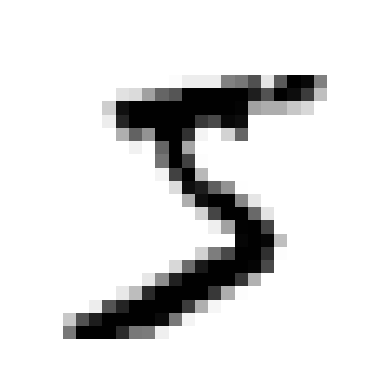

In [9]:
plt.imshow(an_image,cmap=mpl.cm.binary)
plt.axis('off')
plt.show()

In [10]:
y[0]

'5'

In [11]:
y=y.astype(np.int8)

   ###  Train Test Split

In [12]:
X_train,X_test,y_train,y_test=X.iloc[:60000,:],X.iloc[60000:,:],y[:60000],y[60000:]

In [13]:
print("Train_shape:",X_train.shape,y_train.shape)
print('Test_shape: ',X_test.shape,y_test.shape)

Train_shape: (60000, 784) (60000,)
Test_shape:  (10000, 784) (10000,)


# Training a Binary Classifier.
- Let's simplify the problem and just make a binary classifier which tell whether the digit is correct or not.
- Let's use digit `5` for classification


In [14]:
y_train_5=(y_train==5)
y_test_5=(y_test==5)

# Using Stochastic Gradient Descent Classifier.

In [15]:
from sklearn.linear_model import SGDClassifier


In [16]:
sgd_clf=SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

# Using this model to predict some number

In [17]:
sgd_clf.predict([an_image.ravel()])

E:\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [18]:
image_2=X_train.iloc[25].values

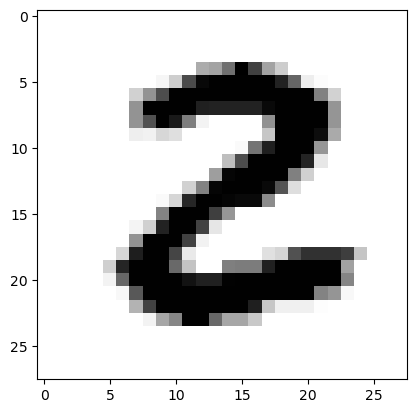

In [19]:
plt.imshow(image_2.reshape(28,28),cmap=mpl.cm.binary)

In [20]:
sgd_clf.predict([image_2])

E:\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([False])

# Performance Measures
 - Performance Measurement of the Classification models is more tricker than that of Regression models

# Measuring Accuracy Using Cross-Validation

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

In [22]:
def cross_val(X_train,y_train):
    accuracy=[]
    skfolds=StratifiedKFold(n_splits=3,random_state=42,shuffle=True)
    for train_indx,test_indx in skfolds.split(X_train,y_train):
        clone_clf=clone(sgd_clf)


        X_train_folds=X_train.iloc[train_indx,:]
        y_train_folds=y_train[train_indx]

        X_test_fold=X_train.iloc[test_indx,:]
        y_test_fold=y_train[test_indx]

        clone_clf.fit(X_train_folds,y_train_folds)
        y_pred=clone_clf.predict(X_test_fold)

        n_correct=sum(y_pred==y_test_fold)
        accuracy.append(n_correct/len(y_pred))
    return accuracy

In [23]:
cross_val(X_train,y_train_5)

[0.9669, 0.91625, 0.96785]

##### `Great.🤔 This model has Accuracy above  91% (Ratio  of correct prediction). That means our model will be correct for the 95% of the time when it makes the prediction.`
- ###### Now Let's Make a Dumb class That doesn't learn anything from the data and says Not-5 everytime when we ask to make prediction.


In [24]:
from sklearn.base import BaseEstimator
from sklearn.model_selection import cross_val_score


In [25]:
class Not5(BaseEstimator):
    def fit(self,X_train,y_train):
        pass  # Does nothing, because this classifier doesn't learn
    
    def predict(self,X_val):
        return np.zeros(shape=(len(X_val),1),dtype=bool) # always returns False.

In [26]:
not5_clf=Not5()
cross_val_score(not5_clf,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.91125, 0.90855, 0.90915])

###### 😮. This classification model has accuracy more that 90%. Meaning that it will be correct for the more that 90% of the time if it just says `not-5`.This is happening because only 10% of the images are`5`.Even though this model is completely useless, it still appears to perform well on accuracy.
##### The Key Lesson.💡
- Accuracy is not always a good measure of model performance, especially with the imbalanced dataset.If one class dominates, a model can get high accuracy just by predicting the majority class.


# Confusion Matrix

In [27]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

- cross_val_predict performs k-fold corss-validation, instead of returning the evaluation scores, it returns the predictions made on each test fold.

In [28]:
y_train_predict=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)

In [29]:
confusion_matrix(y_train_5,y_train_predict)

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

## Rows: Actual values
## Column: Predicted values

- True Negative:53892,
- False Positive:687,
- False Negative:1891,
- True Positive:3530


#### Here we had 60000 images of handwritten digits and out of those 5421 images are 5s.Our model has predicted 4217 images (687+3530) as 5s and 55783 images (53892+1891) are predictaed as Non-5.

#  Precision:
- Precision tells us how many of the predicted 5s are actually correct.That means, How Many Predicted 5s Are Actually 5s?
# $$  Precision=\frac{\text{True Positive}}{\text{True Positive} +\text{False Positive}}$$
###  $$ Precision= \frac{3530}{3530+687}=0.83 $$
- ## That means when our model predicts a `5` it is correct 83% of the time

# Recall:
- Recall tells us how many of the actual 5s were correctly found.That means, How Many of the Real 5s Did We Find?
# $$  Recall = \frac{\text{True Positive}}{\text{True Positive} + \text{False Negative}} $$
###  $$ Recall= \frac{3530}{3530+1891}=0.65 $$
- ## That means our model only found 65% of the real 5s


## The Problem with focusing Only one.
- If Precision is too high,we may be too cautious and miss real 5s.
- If Recall is too high, We may predict too many 5s, leading to many mistakes.

###  Verifying values.


In [30]:
from sklearn.metrics import precision_score,recall_score

In [31]:
print("Precision Score: ",precision_score(y_train_5,y_train_predict))
print("Recall Score: ",recall_score(y_train_5,y_train_predict))

Precision Score:  0.8370879772350012
Recall Score:  0.6511713705958311


 ## Precision/Recall Tradeoff

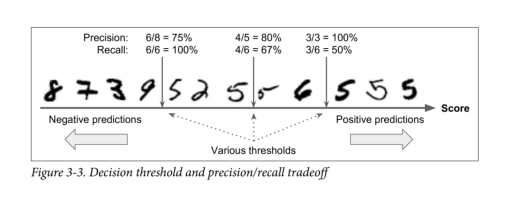

In [32]:
import matplotlib.image as mpimg
img=mpimg.imread('Screenshot 2025-02-22 182151.png')
plt.imshow(img)
plt.axis('off')
plt.show()


In [33]:
y_score=sgd_clf.decision_function(an_image.ravel().reshape(1,-1))

E:\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [34]:
y_score

array([2164.22030239])

In [35]:
threshold=0
y_some_digit_pred=y_score>threshold
y_some_digit_pred

array([ True])

- The SGDClassifier uses a threshold equal to 0, so the previous code returns the same result as the predict() method (i.e., True). Let’s raise the threshold:


In [36]:
threshold=8000
y_some_digit_pred=y_score>threshold
y_some_digit_pred

array([False])

## This Confirms that rising the threshold decreases the recall.That means we mislassified to the Negative class.

- Now how to decide which threshold to use? For this we will need to get the scores of all instances in the trainig set.

In [37]:
y_scores=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3,method='decision_function')

In [38]:
from sklearn.metrics import precision_recall_curve

In [39]:
precisions,recalls,thresholds=precision_recall_curve(y_train_5,y_scores)

In [40]:
precisions

array([0.09035   , 0.09035151, 0.09035301, ..., 1.        , 1.        ,
       1.        ])

In [41]:
def plot_precision_recall_vs_trhreshold(precisons,recalls,thresholds):
    plt.plot(thresholds,precisions[:-1],'b--',label='precision')
    plt.plot(thresholds,recalls[:-1],label='recall')
    plt.xlabel('Threshold')
    plt.title('Precision Recall vs Threshold')
#     finding a good balance
    optimal_idx = np.argmax(precisions[:-1] + recalls[:-1])  # good threshold should maximizes the both metrics together.
    optimal_threshold = thresholds[optimal_idx]

    plt.scatter(optimal_threshold, precisions[optimal_idx], color="red")  # Mark precision
    plt.scatter(optimal_threshold, recalls[optimal_idx], color="red")  # Mark recall

    plt.xlabel("Threshold")
    plt.ylabel("Precision / Recall")
    plt.title("Precision and Recall vs. Decision Threshold")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.axvline(optimal_threshold, color="red", linestyle="dotted")  # Vertical line at optimal threshold
    plt.axhline(precisions[optimal_idx], color="red", linestyle="dotted",label='optimal_precision')  # Horizontal line at precision
    plt.axhline(recalls[optimal_idx], color="green", linestyle="dotted",label='optimal_recalls')
    plt.legend()
    plt.xticks(rotation='vertical')

    plt.show()

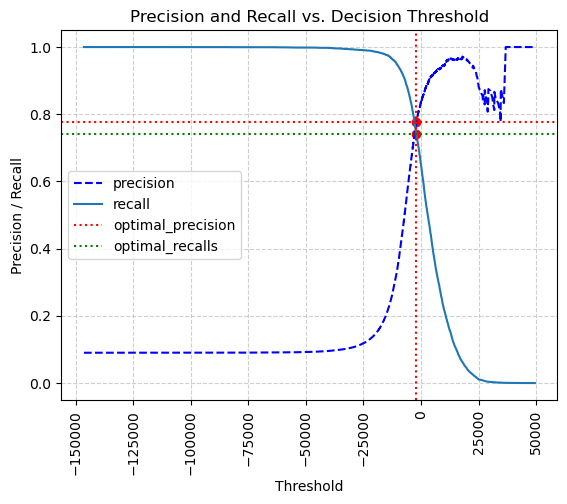

In [42]:
plot_precision_recall_vs_trhreshold(precisions,recalls,thresholds)

 #    Key Observations:
##### Precision(dahsed blue line): 
1. Precision is very low at low threshold and starts to increase as the threshold increases.
2. This behaviour is expreceted becasuse when the threshold is very low, the model predicts more positive, leading to fewer false negative but more false positive.
###### Recall(solid blue line).
1. Recall starts high but drops sharply as the threshold increases.
2. This makes sense: at a low threshold,model predicts more positive and fewer as false Negative, increasing Recall.
###### Optimal Threshold:(Red dotted line and red marker):
1. The vertical red dotted line shows the chosen optimal threshold based on precision + recall.
2. The red dots mark the precision and recall at this threshold.
###### Precision and Recall at the Optimal Threshold:
1. The horizontal red dotted line represents the optimal Precision
2. The horizontal green dotted line represents the optimal Recall.
3. This means the precision is higher than recall.

- Another way to select a good precision vs recall thershold, we could plot precision directly agains the recall.

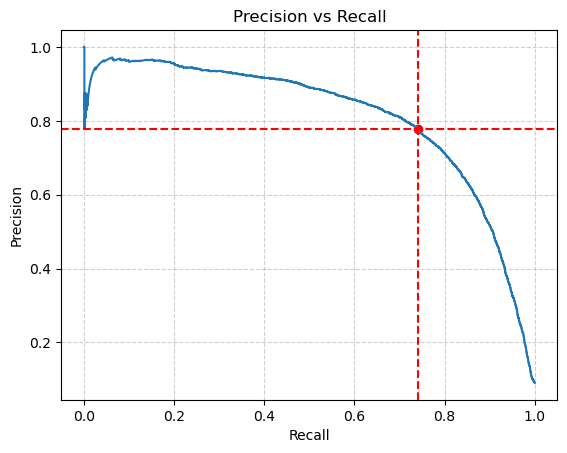

In [43]:
plt.plot(recalls,precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')

optimal_idx=np.argmax(precisions+recalls)
optimal_precision=precisions[optimal_idx]
optimal_recall=recalls[optimal_idx]
plt.scatter(optimal_recall,optimal_precision,c='red')
plt.axvline(optimal_recall,color='red',linestyle='dashed')
plt.axhline(optimal_precision,color='red',linestyle='dashed')
plt.grid(True, linestyle='--',alpha=0.6)
plt.title('Precision vs Recall')
plt.show()




# Overvations:
1. Top-left region (high precision, low recall) : The model is very confident in its positive predictions, but it may miss many true positives.
2. Bottom-right region (low precision, high recall) : The model captures almost all positives but at the cost of many false positives.
3. Middle region (balanced precision-recall) : The model achieves a trade-off, often desirable in many applications

## If we want to select the good balance between the precision and recall , we  should probably select the precision and recall tradeoff just before the sharp drop of precision vs recall curve from the second graph and the corresponding value of threshold from the first graph.

# Suppose we decide to build a model that has 90% of precision:
Then, We should first look up the first plot and for the 90% of precision<br>
programeticall,

In [44]:
threshold_90_precision=thresholds[np.argmax(precisions>=0.9)] # gives the first value of threshold where precision equal to 0.9.

In [45]:
threshold_90_precision

3370.0194991439557

- Now instead of calling the predict() method of classifier just make comparision for simplicity,


In [46]:
y_train_pred_90=y_scores>=threshold_90_precision

In [47]:
y_train_pred_90,len(y_train_pred_90)

(array([False, False, False, ...,  True, False, False]), 60000)

In [48]:
# now precision and recall  scores:
print("precision score of classifier: ",precision_score(y_train_5,y_train_pred_90))
print("recall score of classifier: ",recall_score(y_train_5,y_train_pred_90))

precision score of classifier:  0.9000345901072293
recall score of classifier:  0.4799852425751706


- high `precision classifier` is not very useful if its recall is too low.
# `If someone says “let’s reach 99% precision,” We should ask, “at what recall?”`


# ROC(Receiver Operating Characteristics) Curve
- ROC curve is similar to the Precision-vs-Recall curve but it plots Recall(Ture Positive rate) agains the False Positive Rate(FPR which measures how many actual negative class samples were wrongly classified as Positive).

In [49]:
from sklearn.metrics import roc_curve

In [50]:
fpr,tpr,threshold=roc_curve(y_train_5,y_scores)

In [51]:
def plot_roc_curve(fpr,tpr,label=None):
    plt.plot(fpr,tpr,linewidth=2,label=label)
    
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel("True Positive Rate(TPR)")
    plt.title("ROC Curve")
    plt.plot([0,1],[0,1],linestyle='dashed',c='red')
             


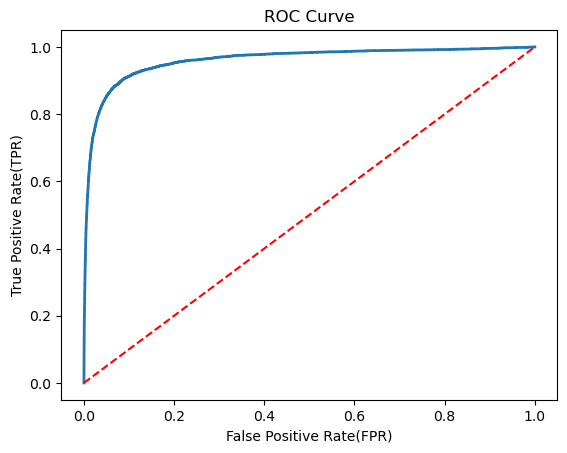

In [52]:
plot_roc_curve(fpr,tpr)

- Once again there is a tradeoff: the higher the recall (TPR), the more false positives<br>
(FPR) the classifier produces. The dotted line represents the ROC curve of a purely<br>
random classifier; a good classifier stays as far away from that line as possible (toward<br>
the top-left corner).

In [53]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

0.9604938554008616

-Since the ROC curve is so similar to the precision/recall (or PR) <br>
curve, we may wonder how to decide which one to use. As a rule<br>
of thumb, we should prefer the PR curve whenever the positive<br>
class is rare or when we care more about the false positives than
the false negatives, and the ROC curve otherwise. For example,<br>
looking at the previous ROC curve (and the ROC AUC score), we<br>
may think that the classifier is really good. But this is mostly<br>
because there are few positives (5s) compared to the negatives<br>
(non-5s). In contrast, the PR curve makes it clear that the classifier<br>
has room for improvement (the curve could be closer to the topright corner).

# Multiclass Classification(Multinomial Classification).
#### Types:
- #### One-vs-All(OvA):- 
- In this classification strategy,If there are N-classes in the target column then N-binary classifiers are created.for example, for the system that classifies the digit images into 10 classes then there would be 10 binary classifiers, one for each digit(0-detector,1-detector and so on). When we want to classify an image,we would pass that image to all classifier and note the decision score and that classifier will be selected which has the highest decision score.

- #### One-vs-One(OvO):-
- In this strategy, a binary classifier will be trained on every pair of digits: a classifier for 0s and 1s, 0s and 2s ... 0s and 9s, 1s and 2s , 1s and 3s and so on for all digits.So if there are N classes we need (n(n-1))/2 classifiers to classify each digits. When we want to  classify the digit, we have to the image through all classifiers and see which classifier has the highest decision score.
- The main advantage of this type of classification strategy is that each classifier only needs to be trained in a part of dataset which reduces the complexities  during training.

###### Scikit-Learn detects when we try to use a binary classification algorithm for a multi‐class classification task, and it automatically runs OvA (except for SVM classifiers for which it uses OvO).

In [54]:
sgd_clf.fit(X_train,y_train)

SGDClassifier(random_state=42)

In [55]:
image_3=X_train.iloc[50]
image_3=image_3.values
y_train[50]

3

In [56]:
y_pred=sgd_clf.predict([image_3])

E:\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [57]:
y_pred

array([3], dtype=int8)

- Acutally Under the hood,Scikit-learn is running 10 different classifiers to classify the data.Now if we check the decision score the we would ge 10 decision scores`

In [58]:
y_scores_3=sgd_clf.decision_function([image_3])

E:\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [59]:
y_scores_3,len(y_scores_3[0])

(array([[-19584.82905069, -18944.92102892,  -7919.67279078,
           6039.69219304,  -9556.93759652,  -1495.61412668,
         -13482.86618687,  -9660.78257371,  -2989.18201979,
         -12452.39783637]]),
 10)

In [60]:
y_scores_3[0,[np.argmax(y_scores_3)]]

array([6039.69219304])

- We can force the Scikit-learn to apply One-Vs-One classification strategy if we want

In [61]:
from sklearn.multiclass import OneVsOneClassifier

ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42)) # takes lots of time.<br>
ovo_clf.fit(X_train, y_train)<br>
ovo_clf.predict([image_3])


len(ovo_clf.estimators_) # return 45 dicision scores.

In [62]:
from sklearn.ensemble import RandomForestClassifier


In [63]:
forest_clf=RandomForestClassifier(random_state=42)
forest_clf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [64]:
forest_clf.predict([image_3])

E:\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([3], dtype=int8)

In [65]:
forest_clf.predict_proba([image_3])

E:\anaconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.01, 0.  , 0.  , 0.97, 0.  , 0.02, 0.  , 0.  , 0.  , 0.  ]])

# Error Analysis

In [66]:
y_train_pred=cross_val_predict(sgd_clf,X_train,y_train,cv=3)

In [67]:
conf_matx=confusion_matrix(y_train,y_train_pred)
conf_matx

array([[5635,    0,   61,   10,   16,   50,   46,    7,   66,   32],
       [   3, 6393,   95,   21,   16,   47,   15,   27,  109,   16],
       [  72,   56, 5174,   89,   69,   39,  163,   66,  212,   18],
       [  58,   32,  217, 4941,   23,  441,   32,   56,  216,  115],
       [  11,   26,   46,    6, 5298,   26,   73,   32,   87,  237],
       [  68,   23,   58,  150,   83, 4606,  174,   26,  152,   81],
       [  40,   13,   56,    6,   22,  113, 5625,    5,   36,    2],
       [  23,   24,  103,   36,  124,   40,   10, 5228,   75,  602],
       [  40,  101,  158,  122,   49,  457,   77,   35, 4666,  146],
       [  33,   18,   66,   83,  515,  127,    4,  485,  166, 4452]],
      dtype=int64)

In [68]:
# heat map of confusion matrix
import seaborn as sns

<Axes: >

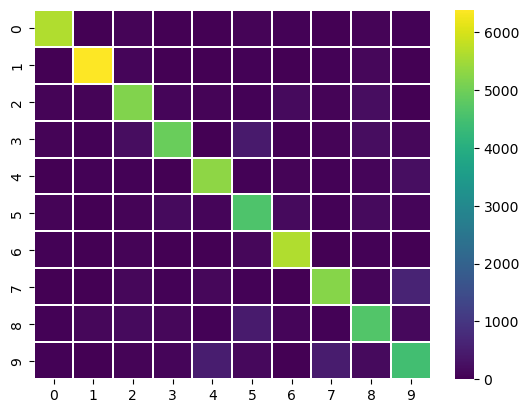

In [72]:
sns.heatmap(conf_matx,cmap='viridis',annot=False,linewidth=0.1)

- The Diagonal elements of confusion matrix shows the number of correctly classified digits.Here, 5,8 and 9 looks slightly darker which could mean that the model didn't perfrom well in that class or they had less number of data points.

# Calculating Error rates(Normalized confusion matrix):
- In a standard confusion matrix, classes with more samples will naturally have higher absolute error counts, 
making their performance look worse.
- By normalizing each row, we get an error rate per class rather than raw misclassifications.


In [85]:
row_sums=conf_matx.sum(axis=1,keepdims=True)
row_sums

array([[5923],
       [6742],
       [5958],
       [6131],
       [5842],
       [5421],
       [5918],
       [6265],
       [5851],
       [5949]], dtype=int64)

In [88]:
norm_conf_matx=conf_matx/row_sums
norm_conf_matx

array([[9.51375992e-01, 0.00000000e+00, 1.02988350e-02, 1.68833361e-03,
        2.70133378e-03, 8.44166807e-03, 7.76633463e-03, 1.18183353e-03,
        1.11430019e-02, 5.40266757e-03],
       [4.44971818e-04, 9.48234945e-01, 1.40907743e-02, 3.11480273e-03,
        2.37318303e-03, 6.97122516e-03, 2.22485909e-03, 4.00474637e-03,
        1.61673094e-02, 2.37318303e-03],
       [1.20845921e-02, 9.39912722e-03, 8.68412219e-01, 1.49378986e-02,
        1.15810675e-02, 6.54582075e-03, 2.73581739e-02, 1.10775428e-02,
        3.55824102e-02, 3.02114804e-03],
       [9.46012070e-03, 5.21937694e-03, 3.53938999e-02, 8.05904420e-01,
        3.75142717e-03, 7.19295384e-02, 5.21937694e-03, 9.13390964e-03,
        3.52307943e-02, 1.87571359e-02],
       [1.88291681e-03, 4.45053064e-03, 7.87401575e-03, 1.02704553e-03,
        9.06881205e-01, 4.45053064e-03, 1.24957206e-02, 5.47757617e-03,
        1.48921602e-02, 4.05682985e-02],
       [1.25438111e-02, 4.24275964e-03, 1.06991330e-02, 2.76701716e-02,
   

- Let's fill the diagonal element of normalized confusion matrix with 0 to keep only errors.


In [89]:
np.fill_diagonal(norm_conf_matx,0)

In [90]:
norm_conf_matx

array([[0.        , 0.        , 0.01029884, 0.00168833, 0.00270133,
        0.00844167, 0.00776633, 0.00118183, 0.011143  , 0.00540267],
       [0.00044497, 0.        , 0.01409077, 0.0031148 , 0.00237318,
        0.00697123, 0.00222486, 0.00400475, 0.01616731, 0.00237318],
       [0.01208459, 0.00939913, 0.        , 0.0149379 , 0.01158107,
        0.00654582, 0.02735817, 0.01107754, 0.03558241, 0.00302115],
       [0.00946012, 0.00521938, 0.0353939 , 0.        , 0.00375143,
        0.07192954, 0.00521938, 0.00913391, 0.03523079, 0.01875714],
       [0.00188292, 0.00445053, 0.00787402, 0.00102705, 0.        ,
        0.00445053, 0.01249572, 0.00547758, 0.01489216, 0.0405683 ],
       [0.01254381, 0.00424276, 0.01069913, 0.02767017, 0.01531083,
        0.        , 0.0320974 , 0.00479616, 0.02803911, 0.01494189],
       [0.00675904, 0.00219669, 0.00946266, 0.00101386, 0.00371747,
        0.01909429, 0.        , 0.00084488, 0.00608314, 0.00033795],
       [0.00367119, 0.00383081, 0.0164405

Text(0.5, 1.0, 'Heat Map of Normalized confusion matrix')

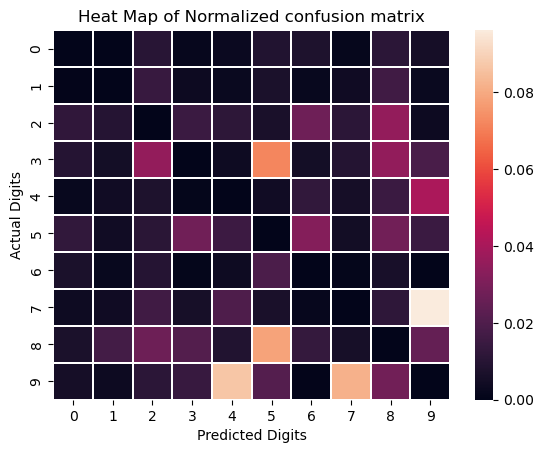

In [92]:
sns.heatmap(norm_conf_matx,linewidth=0.1)
plt.xlabel("Predicted Digits")
plt.ylabel("Actual Digits")
plt.title('Heat Map of Normalized confusion matrix')

- Here column for 8 is quite bright that means many images get misclassified as 8, and if we see row for class 8, it has brighter spots at 1,2,3,5,6,9 which means our model predicted 8 as these numbers.